# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

**1.**  
We use general linear models and activation functions because many outcomes (like probabilities or classes) cannot be modeled well by ordinary linear regression. Linear models can predict values outside valid ranges, while activation functions (like the logistic function) constrain outputs (e.g., between 0 and 1). This makes them better suited for classification and non-continuous outcomes.

**2.**  
Binary and categorical cross entropy are effective because they measure how close predicted probabilities are to the true outcomes and heavily penalize confident incorrect predictions. They are also derived from maximum likelihood estimation, so minimizing cross entropy corresponds to finding the best-fitting model.

**3.**  
**True and false.** Logistic regression is linear in the log-odds (the linear combination of features), but not linear in the predicted probability because of the nonlinear logistic function.

**4.**  
**False.** Logistic regression is specifically designed for classification, since it outputs probabilities that can be thresholded to assign class labels.

**5.**  
**No.** The coefficient represents the change in the **log-odds** for a 1-unit increase in the feature, not the direct change in predicted probability.

**6.**  
**False.** Feature engineering is still important because logistic regression is only nonlinear due to the activation function; the relationship between features and the log-odds is still linear. Transformations and interactions can improve the model.

**7.**  
**False.** Logistic regression is better for classification problems, but ordinary linear regression is still appropriate for continuous outcomes. You should choose the model based on the type of problem, not always default to logistic regression.


**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [58]:
import warnings
warnings.filterwarnings("ignore")

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score

#2.1
q2 = pd.read_csv("./data/data.csv", sep=";")

q2.columns = q2.columns.str.strip()

print(q2.columns.tolist())

q2 = q2[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]].copy()

q2 = q2.dropna()

q2["dropout"] = (q2["Target"] == "Dropout").astype(int)

#2.2
X = q2[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment"
]]

y = q2["dropout"]

logit = LogisticRegression(max_iter=5000)
logit.fit(X, y)

coef = pd.Series(logit.coef_[0], index=X.columns)
print("Intercept:", logit.intercept_[0])
coef

['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target']
Intercept: 0.

Debtor                     0.530625
Tuition fees up to date   -2.556542
Scholarship holder        -1.227442
Age at enrollment          0.049925
dtype: float64

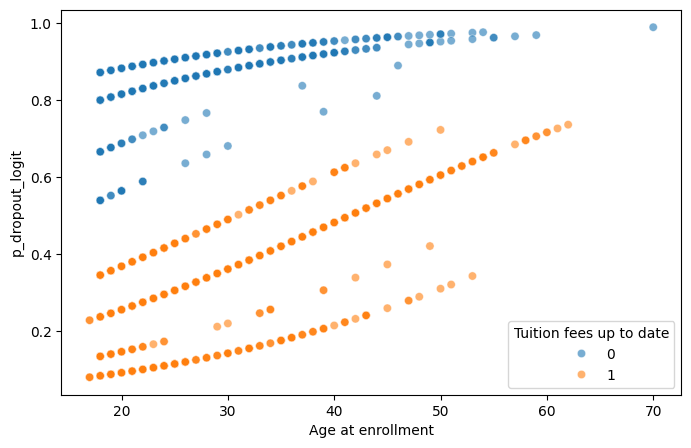

In [60]:
#2.3 
q2["p_dropout_logit"] = logit.predict_proba(X)[:, 1]

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=q2,
    x="Age at enrollment",
    y="p_dropout_logit",
    hue="Tuition fees up to date",
    alpha=0.6
)
plt.show()



In [61]:
#2.3
X_up = X.copy()
X_not = X.copy()

X_up["Tuition fees up to date"] = 1
X_not["Tuition fees up to date"] = 0

p_up = logit.predict_proba(X_up)[:, 1]
p_not = logit.predict_proba(X_not)[:, 1]

q2["tuition_effect"] = p_up - p_not

q2["tuition_effect"].mean()

np.float64(-0.516181974220566)

In [62]:
#2.4
yhat = logit.predict(X)

confusion_matrix(y, yhat), accuracy_score(y, yhat)

(array([[2841,  162],
        [ 891,  530]]),
 0.7619801084990958)

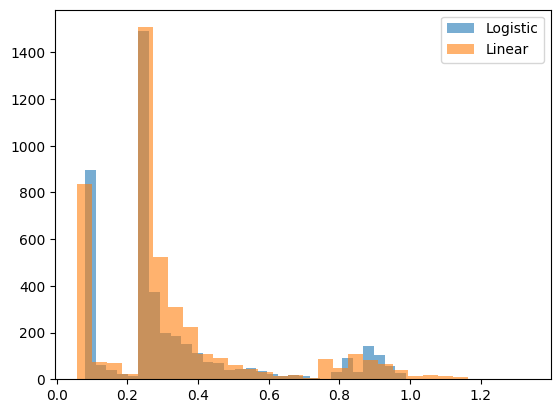

In [63]:
#2.5
lin = LinearRegression()
lin.fit(X, y)

q2["p_dropout_linear"] = lin.predict(X)

plt.hist(q2["p_dropout_logit"], bins=30, alpha=0.6, label="Logistic")
plt.hist(q2["p_dropout_linear"], bins=30, alpha=0.6, label="Linear")
plt.legend()
plt.show()

In [64]:
#2.6
X_multi = q2[[
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]]
y_multi = q2["Target"]

multi = LogisticRegression(max_iter=5000, multi_class="multinomial")
multi.fit(X_multi, y_multi)

pred_multi = multi.predict(X_multi)

confusion_matrix(y_multi, pred_multi), accuracy_score(y_multi, pred_multi)

(array([[1054,    0,  367],
        [ 280,    0,  514],
        [ 146,    0, 2063]]),
 0.7045660036166366)

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

In [65]:
q3 = pd.read_csv("./data/cirrhosis.csv")

# clean column names
q3.columns = q3.columns.str.strip()

# keep needed columns
q3 = q3[["Bilirubin", "Edema", "Drug", "Stage", "Status"]].copy()

# drop missing
q3 = q3.replace([np.inf, -np.inf], np.nan)
q3 = q3.dropna()

q3.head()

,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,D
1,1.1,N,D-penicillamine,3.0,C
2,1.4,S,D-penicillamine,4.0,D
3,1.8,S,D-penicillamine,4.0,D
4,3.4,N,Placebo,3.0,CL


### 3.1

Missing values were removed using `.dropna()`. Rows with missing values in Drug, Bilirubin, Edema, Stage, or Status were excluded to ensure clean model estimation.

In [66]:
#3.1
q3["alive"] = q3["Status"].isin(["C", "CL"]).astype(int)

In [67]:
#3.2
X_q3 = pd.get_dummies(q3[["Edema", "Drug", "Bilirubin"]], drop_first=True)
y_q3 = q3["alive"]

logit_q3 = LogisticRegression(max_iter=5000)
logit_q3.fit(X_q3, y_q3)

coef_q3 = pd.Series(logit_q3.coef_[0], index=X_q3.columns)
print("Intercept:", logit_q3.intercept_[0])
coef_q3

Intercept: 1.3798277993022927


Bilirubin      -0.351424
Edema_S        -0.450677
Edema_Y        -1.611049
Drug_Placebo    0.231225
dtype: float64

### 3.2

Positive coefficients increase survival probability, while negative coefficients decrease it.

Bilirubin should have a negative effect on survival since higher bilirubin indicates worse liver function. More severe edema should also reduce survival probability. The drug coefficient shows whether D-penicillamine improves survival relative to placebo.

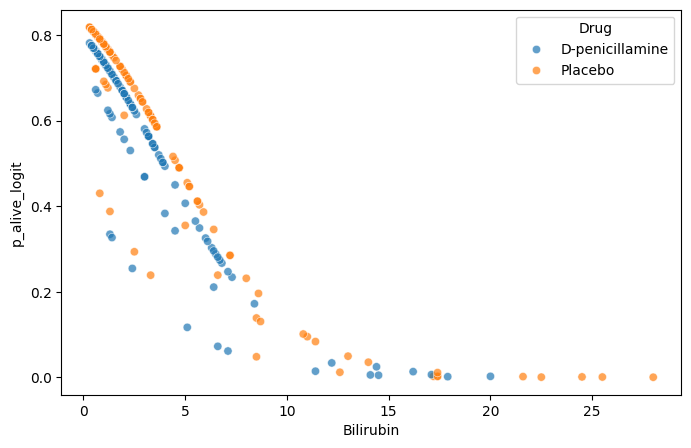

In [68]:
#3.3
q3["p_alive_logit"] = logit_q3.predict_proba(X_q3)[:, 1]

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=q3,
    x="Bilirubin",
    y="p_alive_logit",
    hue="Drug",
    alpha=0.7
)
plt.show()

In [69]:
#3.3
X_raw = q3[["Edema", "Drug", "Bilirubin"]].copy()

X_drug = X_raw.copy()
X_placebo = X_raw.copy()

X_drug["Drug"] = "D-penicillamine"
X_placebo["Drug"] = "Placebo"

X_drug = pd.get_dummies(X_drug, drop_first=True)
X_placebo = pd.get_dummies(X_placebo, drop_first=True)

# align columns
X_drug = X_drug.reindex(columns=X_q3.columns, fill_value=0)
X_placebo = X_placebo.reindex(columns=X_q3.columns, fill_value=0)

p_drug = logit_q3.predict_proba(X_drug)[:, 1]
p_placebo = logit_q3.predict_proba(X_placebo)[:, 1]

q3["treatment_effect"] = p_drug - p_placebo

q3["treatment_effect"].mean()

np.float64(0.0)

### 3.3
The scatterplot shows how survival probability changes with bilirubin across treatment groups. If the drug is effective, its curve should lie above placebo.

The average treatment effect is the mean of the difference between predicted survival under drug vs placebo. A positive value indicates the drug improves survival probability.

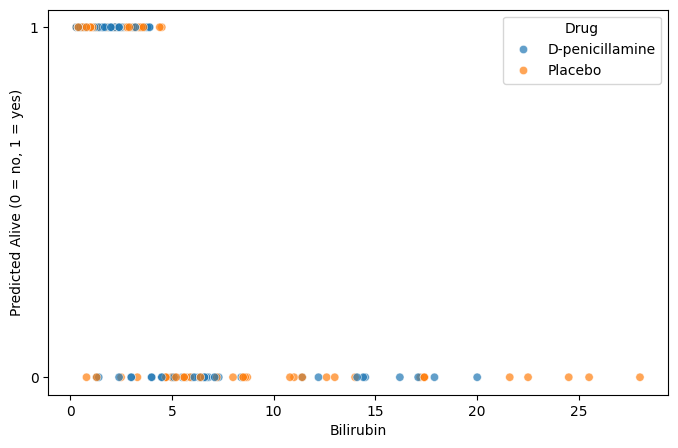

In [70]:
#3.4
q3["yhat"] = logit_q3.predict(X_q3)

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=q3,
    x="Bilirubin",
    y="yhat",
    hue="Drug",
    alpha=0.7
)
plt.yticks([0,1])
plt.ylabel("Predicted Alive (0 = no, 1 = yes)")
plt.show()

In [71]:
#3.4

yhat_q3 = logit_q3.predict(X_q3)

confusion_matrix(y_q3, yhat_q3), accuracy_score(y_q3, yhat_q3)

(array([[ 59,  66],
        [ 16, 171]]),
 0.7371794871794872)

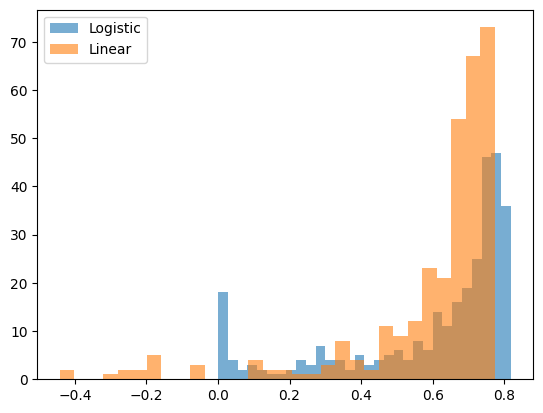

In [72]:
#3.5 
lin_q3 = LinearRegression()
lin_q3.fit(X_q3, y_q3)

q3["p_alive_linear"] = lin_q3.predict(X_q3)


plt.hist(q3["p_alive_logit"], bins=30, alpha=0.6, label="Logistic")
plt.hist(q3["p_alive_linear"], bins=30, alpha=0.6, label="Linear")
plt.legend()
plt.show()

In [73]:
#3.5 
(q3["p_alive_linear"].min(), q3["p_alive_linear"].max())

(np.float64(-0.44173966839359946), np.float64(0.7738680250928712))

In [74]:
#3.6
X_stage = pd.get_dummies(q3[["Edema", "Bilirubin"]], drop_first=True)
y_stage = q3["Stage"].astype(int)

stage_model = LogisticRegression(max_iter=5000)
stage_model.fit(X_stage, y_stage)

pred_stage = stage_model.predict(X_stage)

confusion_matrix(y_stage, pred_stage), accuracy_score(y_stage, pred_stage)

(array([[  0,   0,  16,   0],
        [  0,   0,  63,   4],
        [  0,   0, 105,  15],
        [  0,   0,  79,  30]]),
 0.4326923076923077)

In [75]:
#3.6
proba_stage = pd.DataFrame(
    stage_model.predict_proba(X_stage),
    columns=stage_model.classes_
)

proba_stage.head()

,1,2,3,4
0,0.000013,0.032535,0.143611,0.823841
1,0.072394,0.251555,0.397520,0.278531
2,0.029263,0.181531,0.395694,0.393512
3,0.023272,0.176777,0.397217,0.402734
4,0.020204,0.224965,0.423342,0.331488


### 3.6
The hard classification assigns each observation to a single stage, but may not predict all stages equally often.

The predicted probabilities provide more information because they assign a probability to every stage for each observation. Even when a class is rarely chosen in hard classification, it still appears in the probability outputs, making them more informative.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

### 4.1

The derivative of the prediction with respect to the k-th feature is:

$$
\frac{\partial \hat{y}}{\partial x_k} = b_k
$$

So for a 1-unit increase in $x_k$, the prediction increases by exactly $b_k$, holding all other variables fixed.

### 4.2

For the logistic model,

$$
\hat{p} = \frac{e^{b \cdot x}}{1 + e^{b \cdot x}}
$$

Using the chain rule, the derivative with respect to $x_k$ is:

$$
\frac{\partial \hat{p}}{\partial x_k} = \hat{p}(1 - \hat{p}) \, b_k
$$

Unlike the linear model, this depends on $\hat{p}$, so the effect of a 1-unit change in $x_k$ is not constant and changes with $x$.

The coefficient times 4 is a good approximation of the change in predicted probability when $\hat{p} \approx 0.5$, because $\hat{p}(1-\hat{p})$ is maximized at 0.25.

### 4.3 

From

$$
\log\left(\frac{\hat{p}}{1 - \hat{p}}\right) = b \cdot x
$$

a 1-unit increase in $x_k$ increases the log-odds ratio by:

$$
b_k
$$

So the coefficient represents the change in log-odds for a one-unit increase in the feature, holding all other variables constant.